# 🛡️ AI in Cyber Security Capstone Project: Threat Detection & Analysis
**Repository:** `ai-cybersecurity-unit1-mini-project-anant-goel`  
**Dataset:** UNSW-NB15 Network Intrusion Detection Dataset  
**Objective:** End-to-end implementation of Workspace Bootstrap, Exploratory Threat Landscape Analysis (EDA), Supervised Machine Learning Threat Classification, and Deep Learning Neural Prototype Evaluation.

---

### Project Roadmap
1. **Task 1: Workspace Bootstrap & Environment Setup**
   - Repository scaffolding, virtual environment verification, dependency auditing, dataset schema verification.
2. **Task 2: Cyber Security Threat Landscape Analysis (EDA)**
   - Behavioral profiling of normal vs. malicious network traffic, attack category taxonomies, packet rate/duration anomalies, and correlation indicators.
3. **Task 3: Basic Machine Learning-Based Threat Classification**
   - End-to-end preprocessing pipeline (imputation, categorical encoding, feature scaling), training Logistic Regression and Decision Tree models, comprehensive evaluation (Precision, Recall, F1, ROC-AUC).
4. **Task 4: Introduction to Deep Learning Concepts (Prototype Implementation)**
   - Multi-Layer Perceptron (MLP) neural network implementation, loss convergence tracking, comparative benchmarking (ML vs DL on accuracy, latency, and SOC operational feasibility).


## 📦 Task 1: Workspace Bootstrap & Environment Setup
In this task, we initialize the analytical environment, verify that all necessary data science and machine learning packages (`numpy`, `pandas`, `scikit-learn`, `matplotlib`, `seaborn`) are loaded from our isolated Python virtual environment (`.venv`), and inspect the dataset files placed in the `data/` directory.


In [1]:
# Environment & Library Verification
import sys
import os
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("=" * 65)
print("  AI IN CYBERSECURITY: ENVIRONMENT VERIFICATION")
print("=" * 65)
print(f"Python Version    : {sys.version.split()[0]}")
print(f"Python Executable : {sys.executable}")
print(f"NumPy Version     : {np.__version__}")
print(f"Pandas Version    : {pd.__version__}")
print(f"Scikit-Learn      : {sklearn.__version__}")
print(f"Matplotlib        : {plt.matplotlib.__version__}")
print(f"Seaborn           : {sns.__version__}")
print("=" * 65)

# Visual Aesthetics Configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['figure.dpi'] = 120


  AI IN CYBERSECURITY: ENVIRONMENT VERIFICATION
Python Version    : 3.13.2
Python Executable : C:\Users\konik\Downloads\AI in Cyber Security Project\.venv\Scripts\python.exe
NumPy Version     : 2.5.3
Pandas Version    : 3.0.6
Scikit-Learn      : 1.9.1
Matplotlib        : 3.11.2
Seaborn           : 0.13.2


### 📂 Dataset Ingestion & Schema Audit
The **UNSW-NB15** dataset was created by the Cyber Range Lab of the Australian Centre for Cyber Security (ACCS) using an IXIA PerfectStorm tool to simulate real-world modern network behaviors containing normal activities and synthetic contemporary attack behaviors.

Here we ingest the dataset partitions from the local `data/` directory:
- `data/UNSW_NB15_training-set.csv` (82,332 records)
- `data/UNSW_NB15_testing-set.csv` (175,341 records)


In [2]:
# Load the training and testing datasets
train_path = os.path.join('..', 'data', 'UNSW_NB15_training-set.csv') if os.path.exists(os.path.join('..', 'data')) else os.path.join('data', 'UNSW_NB15_training-set.csv')
test_path = os.path.join('..', 'data', 'UNSW_NB15_testing-set.csv') if os.path.exists(os.path.join('..', 'data')) else os.path.join('data', 'UNSW_NB15_testing-set.csv')

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

print(f"Training Dataset Shape: {df_train.shape[0]:,} rows x {df_train.shape[1]} features")
print(f"Testing Dataset Shape : {df_test.shape[0]:,} rows x {df_test.shape[1]} features")
print("\nInitial 5 Records Preview:")
df_train.head()


Training Dataset Shape: 82,332 rows x 45 features
Testing Dataset Shape : 175,341 rows x 45 features

Initial 5 Records Preview:


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


## 🔍 Task 2: Cyber Security Threat Landscape Analysis (EDA)
Exploratory Data Analysis (EDA) in cybersecurity provides crucial visibility into traffic patterns, anomaly baselines, and specific attack vectors.

In this section, we analyze:
1. **Target Distribution**: Ratio of benign (Normal `0`) vs. malicious/suspicious (Attack `1`) events.
2. **Threat Taxonomy**: Frequency and categorization of the 9 attack families (`Generic`, `Exploits`, `Fuzzers`, `DoS`, `Reconnaissance`, `Analysis`, `Backdoor`, `Shellcode`, `Worms`).
3. **Behavioral Indicators**:
   - Packet Velocity (`rate`) and Flow Duration (`dur`).
   - Source-to-destination byte volume (`sbytes`) vs. destination-to-source (`dbytes`).
   - Time-to-Live (`sttl` vs `dttl`) anomalies indicative of spoofed operating systems or hop alterations.
   - Transport layer protocols (`proto`) and application services (`service`).
4. **Correlation Analysis**: Quantifying which network telemetry attributes correlate strongest with malicious intent.


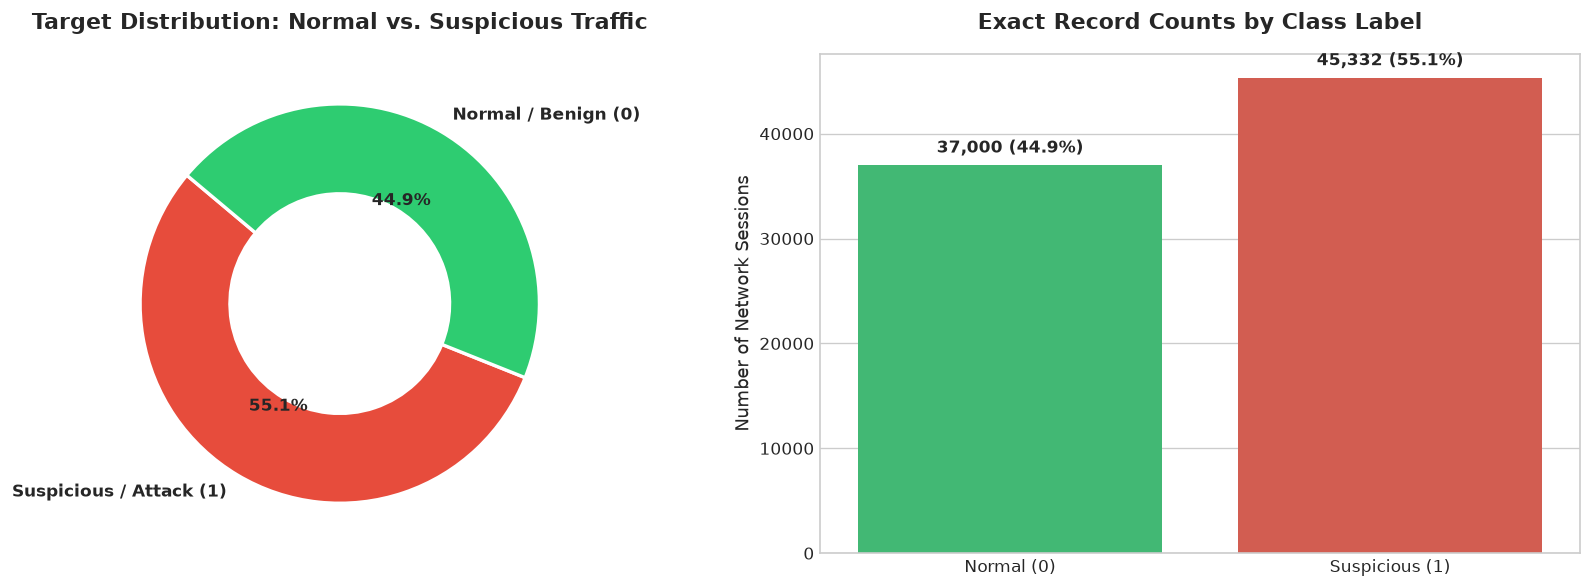

Total Sessions Analyzed : 82,332
Normal (Benign) Sessions: 37,000 (44.94%)
Suspicious (Attack)     : 45,332 (55.06%)


In [3]:
# 1. Target Label Distribution (Normal vs. Suspicious)
label_counts = df_train['label'].value_counts()
label_proportions = df_train['label'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Donut Chart
colors_binary = ['#2ECC71', '#E74C3C']  # Green for Normal, Red for Attack
wedges, texts, autotexts = axes[0].pie(
    label_counts, 
    labels=['Suspicious / Attack (1)', 'Normal / Benign (0)'],
    autopct='%1.1f%%',
    startangle=140,
    colors=[colors_binary[1], colors_binary[0]],
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2),
    textprops=dict(weight='bold')
)
axes[0].set_title('Target Distribution: Normal vs. Suspicious Traffic', fontsize=13, weight='bold', pad=15)

# Count Barplot
sns.barplot(x=['Normal (0)', 'Suspicious (1)'], y=[label_counts[0], label_counts[1]], palette=['#2ECC71', '#E74C3C'], ax=axes[1])
axes[1].set_title('Exact Record Counts by Class Label', fontsize=13, weight='bold', pad=15)
axes[1].set_ylabel('Number of Network Sessions')
for i, v in enumerate([label_counts[0], label_counts[1]]):
    axes[1].text(i, v + 1200, f"{v:,} ({label_proportions.iloc[1-i]:.1f}%)", ha='center', weight='bold')

plt.tight_layout()
plt.show()

print(f"Total Sessions Analyzed : {len(df_train):,}")
print(f"Normal (Benign) Sessions: {label_counts[0]:,} ({label_proportions[0]:.2f}%)")
print(f"Suspicious (Attack)     : {label_counts[1]:,} ({label_proportions[1]:.2f}%)")


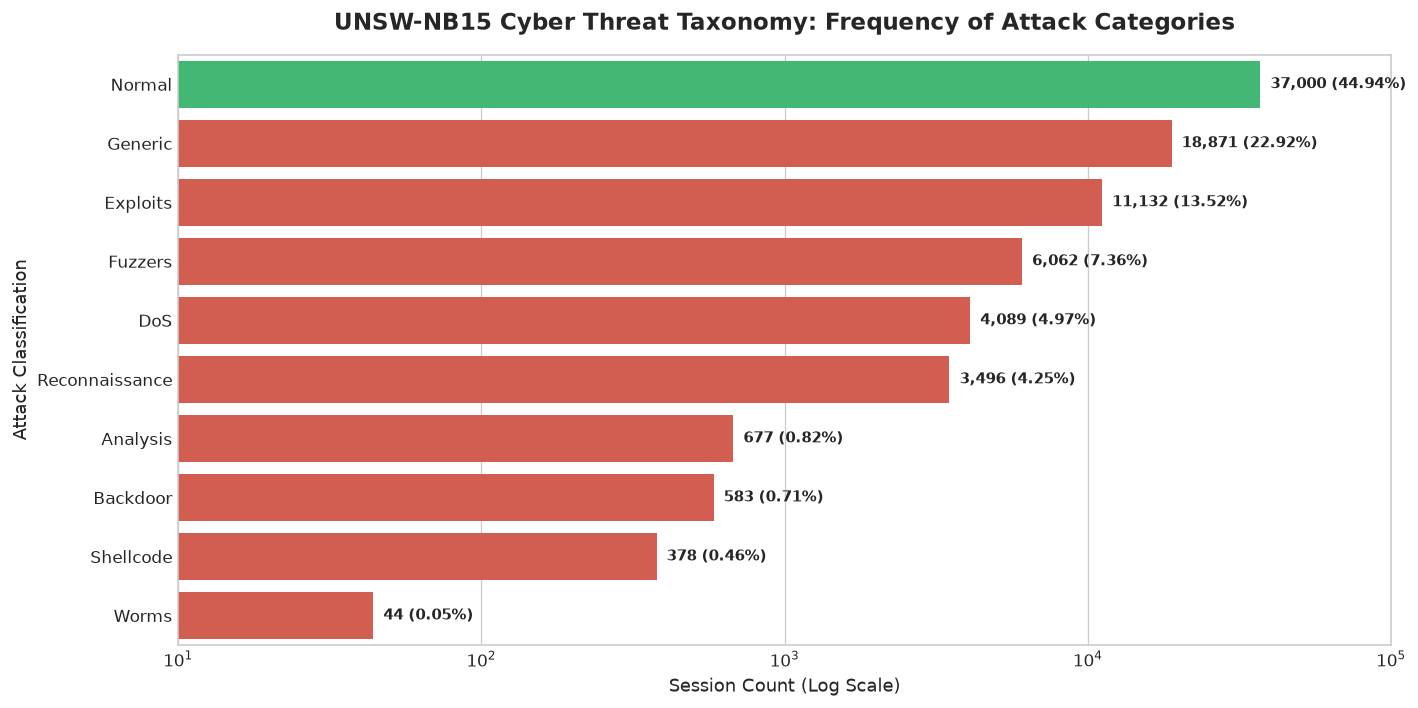

In [4]:
# 2. Detailed Threat Taxonomy (Attack Category Distribution)
attack_cat_counts = df_train['attack_cat'].value_counts()

plt.figure(figsize=(12, 6))
palette = ['#2ECC71' if cat == 'Normal' else '#E74C3C' for cat in attack_cat_counts.index]
sns.barplot(x=attack_cat_counts.values, y=attack_cat_counts.index, palette=palette)

plt.title('UNSW-NB15 Cyber Threat Taxonomy: Frequency of Attack Categories', fontsize=14, weight='bold', pad=15)
plt.xlabel('Session Count (Log Scale)', fontsize=11)
plt.xscale('log')
plt.ylabel('Attack Classification', fontsize=11)

for idx, (cat, val) in enumerate(attack_cat_counts.items()):
    pct = (val / len(df_train)) * 100
    plt.text(val * 1.08, idx, f"{val:,} ({pct:.2f}%)", va='center', fontsize=9, weight='bold')

plt.xlim(10, 100000)
plt.tight_layout()
plt.show()


### 📊 Threat Indicator 1: Source-to-Destination Byte Volume vs. Session Duration
In network intrusion detection, attacks exhibit distinctive physical traffic footprints:
- **Denial of Service (DoS) & Brute Force**: Short burst duration with high transmission volume or high packet rates.
- **Data Exfiltration**: Extended duration with heavily asymmetric source byte transmission.
- **Reconnaissance / Scans**: Minimal duration, minimal bytes, targeting multiple ports.


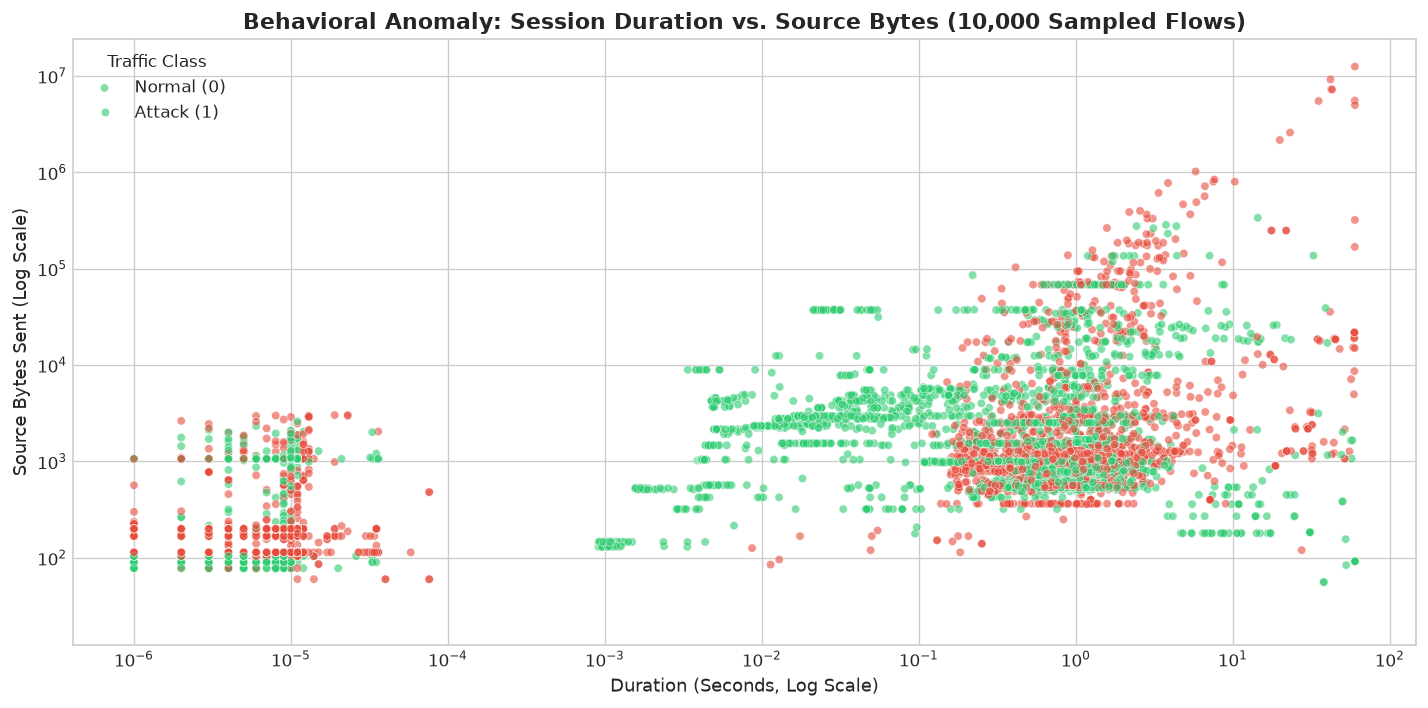

In [5]:
# Scatter Plot: Session Duration vs Source Bytes (Log Scale)
sample_df = df_train.sample(n=10000, random_state=42)

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=sample_df,
    x='dur',
    y='sbytes',
    hue='label',
    palette={0: '#2ECC71', 1: '#E74C3C'},
    alpha=0.6,
    s=25
)
plt.xscale('log')
plt.yscale('log')
plt.title('Behavioral Anomaly: Session Duration vs. Source Bytes (10,000 Sampled Flows)', fontsize=13, weight='bold')
plt.xlabel('Duration (Seconds, Log Scale)')
plt.ylabel('Source Bytes Sent (Log Scale)')
plt.legend(title='Traffic Class', labels=['Normal (0)', 'Attack (1)'])
plt.tight_layout()
plt.show()


### 📊 Threat Indicator 2: Time-To-Live (TTL) and Packet Velocity Anomalies
The `sttl` (Source-to-Destination Time-To-Live) and `rate` (Packets per second) features serve as high-conviction signatures:
- Threat actors often use forged raw packet headers or randomized TTL values during automated scanning and exploitation.
- Legitimate operating systems use standard initial TTL values (e.g., 64 for Linux, 128 for Windows, 255 for network hardware).


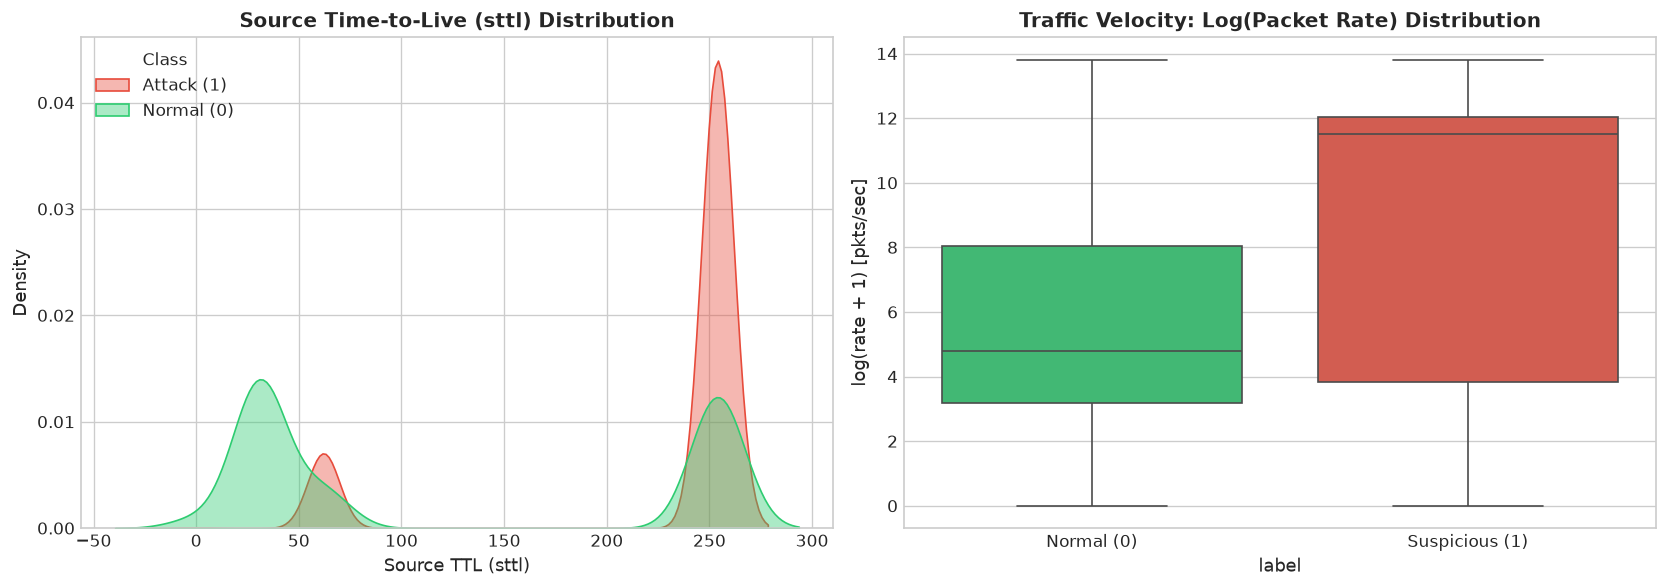

In [6]:
# Distribution of Source TTL and Packet Rate
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# STTL Distribution by Label
sns.kdeplot(data=df_train, x='sttl', hue='label', common_norm=False, palette={0: '#2ECC71', 1: '#E74C3C'}, fill=True, alpha=0.4, ax=axes[0])
axes[0].set_title('Source Time-to-Live (sttl) Distribution', fontsize=12, weight='bold')
axes[0].set_xlabel('Source TTL (sttl)')
axes[0].legend(title='Class', labels=['Attack (1)', 'Normal (0)'])

# Packet Rate Distribution (Log Scale)
df_train['log_rate'] = np.log1p(df_train['rate'])
sns.boxplot(x='label', y='log_rate', data=df_train, palette=['#2ECC71', '#E74C3C'], ax=axes[1])
axes[1].set_xticklabels(['Normal (0)', 'Suspicious (1)'])
axes[1].set_title('Traffic Velocity: Log(Packet Rate) Distribution', fontsize=12, weight='bold')
axes[1].set_ylabel('log(rate + 1) [pkts/sec]')

plt.tight_layout()
plt.show()


### 📊 Threat Indicator 3: Top Protocols and Correlation Matrix of Core Features
Let's inspect the protocols targeted by attacks and visualize the Pearson correlation coefficients between key traffic telemetry variables and the target threat label.


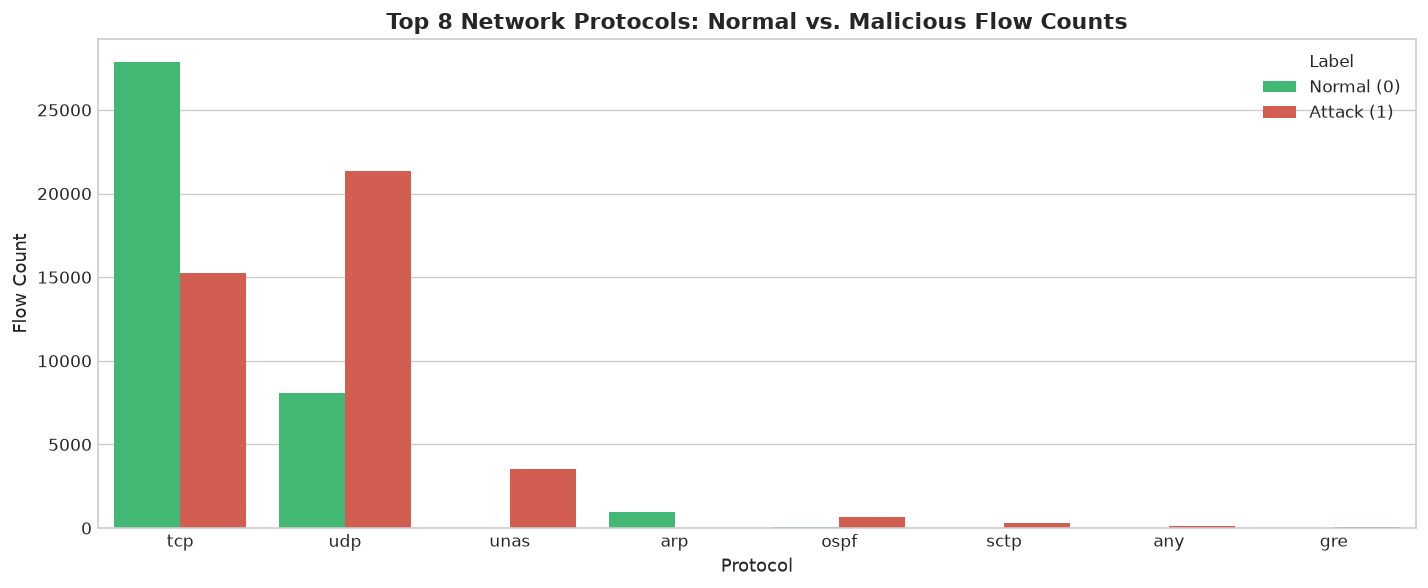

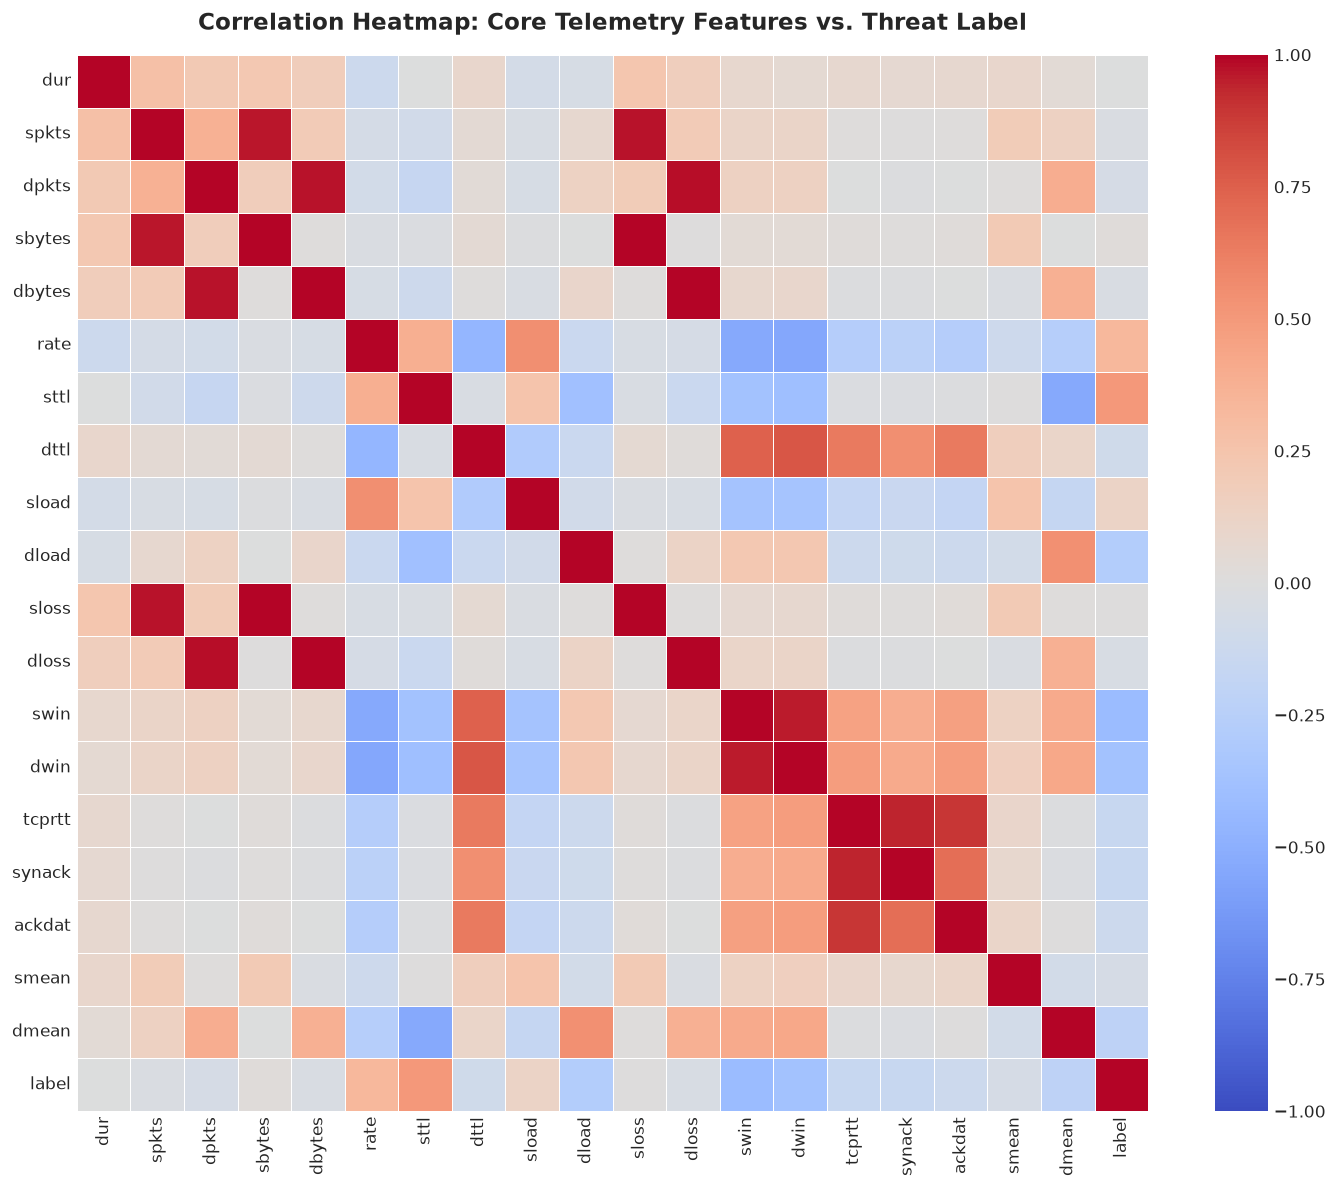

Top 10 Positively Correlated Features with Malicious Label:
sttl      0.504159
rate      0.328629
sload     0.124548
sbytes    0.020641
sloss     0.006360
dur      -0.001145
spkts    -0.027731
dbytes   -0.032632
dloss    -0.044399
smean    -0.061146
Name: label, dtype: float64


In [7]:
# Top 10 Protocols Distribution across Normal vs Attack
top_protos = df_train['proto'].value_counts().nlargest(8).index
proto_filtered = df_train[df_train['proto'].isin(top_protos)]

plt.figure(figsize=(12, 5))
sns.countplot(
    data=proto_filtered, 
    x='proto', 
    hue='label', 
    palette={0: '#2ECC71', 1: '#E74C3C'},
    order=top_protos
)
plt.title('Top 8 Network Protocols: Normal vs. Malicious Flow Counts', fontsize=13, weight='bold')
plt.xlabel('Protocol')
plt.ylabel('Flow Count')
plt.legend(title='Label', labels=['Normal (0)', 'Attack (1)'])
plt.tight_layout()
plt.show()

# Correlation Heatmap of Selected High-Impact Features
core_features = [
    'dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 
    'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 
    'swin', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'label'
]

corr = df_train[core_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=False, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap: Core Telemetry Features vs. Threat Label', fontsize=14, weight='bold', pad=15)
plt.tight_layout()
plt.show()

# Print Top Correlated Features with Detection Label
top_corr = corr['label'].drop('label').sort_values(ascending=False)
print("Top 10 Positively Correlated Features with Malicious Label:")
print(top_corr.head(10))


### 📝 Summary of Threat Landscape Analysis (EDA Key Findings)
| Threat Indicator | Benign / Normal Behavior Baseline | Suspicious / Attack Behavior Pattern | Security Impact |
| :--- | :--- | :--- | :--- |
| **Source TTL (`sttl`)** | Clustered strictly around standard RFC operating system defaults (64, 128) | High concentration at anomalous boundaries (e.g., 254) | Clear indicator of spoofed traffic and scanning tools |
| **Packet Rate (`rate`)** | Stable, controlled transmission rates matching normal user applications | Extremely high spikes during DoS and Fuzzing bursts | Volume anomaly detection enables perimeter thresholding |
| **Byte Asymmetry (`sbytes`/`dbytes`)** | Balanced request-response payloads (e.g., HTTP requests followed by larger downloads) | Massive outbound source payloads (exfiltration) or empty ACK/SYN floods | Flag data exfiltration and SYN flooding |
| **Protocol Targeting** | Standard transport layer traffic (TCP/UDP) with expected port services | Broad exploitation spanning raw protocols (`ospf`, `unas`, `arp`) and fuzzing | Protocol anomalies should trigger deep packet inspection |


## 🤖 Task 3: Basic Machine Learning-Based Threat Classification
In this task, we build an end-to-end supervised machine learning pipeline to classify incoming network telemetry as either normal or suspicious.

### 1. Preprocessing Workflow
- **Data Sanitization**: Drop non-predictive identifiers (`id`, `log_rate`) and the multiclass target (`attack_cat`), retaining binary target `label`.
- **Missing Value Audit**: Check and handle missing or null attributes.
- **Categorical Feature Encoding**:
  - `proto`: Group rare protocols (outside the top 10) into `'other'` to mitigate feature explosion, followed by `OneHotEncoder`.
  - `service` & `state`: One-Hot Encoded.
- **Numerical Scaling**: High variance network metrics (`sbytes`, `rate`, `sload`) span orders of magnitude; we normalize them using `StandardScaler` ($z = \frac{x - \mu}{\sigma}$).
- **Stratified Train-Validation Split**: 75% training, 25% validation, preserving malicious-to-benign ratios.

### 2. Model Implementations
- **Logistic Regression**: A linear model with $L2$ regularization serving as our foundational baseline.
- **Decision Tree Classifier**: A non-linear, hierarchical rule-based classifier that provides tree-based explainability for SOC analysts.

### 3. Evaluation Criteria
- **Accuracy**: Overall classification correctness.
- **Precision**: $\frac{TP}{TP + FP}$ — Low precision means excessive False Positives (alert fatigue for SOC analysts).
- **Recall**: $\frac{TP}{TP + FN}$ — Low recall means False Negatives (breaches slipping through undetected).
- **F1-Score**: Harmonic mean balancing precision and recall.
- **Confusion Matrix & ROC-AUC**.


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    classification_report, confusion_matrix, roc_curve, auc
)

# 1. Feature & Target Isolation
drop_cols = ['id', 'attack_cat', 'label']
if 'log_rate' in df_train.columns:
    drop_cols.append('log_rate')

X = df_train.drop(columns=drop_cols)
y = df_train['label']

# 2. Missing Value Audit
missing_counts = X.isnull().sum().sum()
print(f"Total Missing Values in Dataset: {missing_counts}")

# 3. Handle High-Cardinality Categorical Features
cat_cols = ['proto', 'service', 'state']
num_cols = [c for c in X.columns if c not in cat_cols]

# Group rare protocols
top_10_protos = X['proto'].value_counts().nlargest(10).index
X['proto'] = X['proto'].apply(lambda x: x if x in top_10_protos else 'other')

# 4. Construct Scikit-Learn Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

# 5. Stratified Train-Validation Splitting
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Fit on training data and transform both sets
X_train = preprocessor.fit_transform(X_train_raw)
X_val = preprocessor.transform(X_val_raw)

encoded_cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()
all_feature_names = num_cols + encoded_cat_names

print(f"Processed Training Matrix Shape: {X_train.shape[0]:,} samples x {X_train.shape[1]} features")
print(f"Processed Validation Matrix Shape: {X_val.shape[0]:,} samples x {X_val.shape[1]} features")


Total Missing Values in Dataset: 0


Processed Training Matrix Shape: 61,749 samples x 69 features
Processed Validation Matrix Shape: 20,583 samples x 69 features


In [9]:
# 1. Train Logistic Regression Model
print("Training Logistic Regression Model...")
t0_lr = time.time()
lr_model = LogisticRegression(max_iter=500, random_state=42, solver='lbfgs')
lr_model.fit(X_train, y_train)
train_time_lr = time.time() - t0_lr

# Predictions and Probabilities
y_pred_lr = lr_model.predict(X_val)
y_prob_lr = lr_model.predict_proba(X_val)[:, 1]

# 2. Train Decision Tree Classifier Model
print("Training Decision Tree Classifier...")
t0_dt = time.time()
dt_model = DecisionTreeClassifier(max_depth=12, min_samples_split=20, random_state=42)
dt_model.fit(X_train, y_train)
train_time_dt = time.time() - t0_dt

# Predictions and Probabilities
y_pred_dt = dt_model.predict(X_val)
y_prob_dt = dt_model.predict_proba(X_val)[:, 1]

print(f"\nLogistic Regression Training Time: {train_time_lr:.2f} seconds")
print(f"Decision Tree Training Time      : {train_time_dt:.2f} seconds")


Training Logistic Regression Model...


Training Decision Tree Classifier...



Logistic Regression Training Time: 3.86 seconds
Decision Tree Training Time      : 1.43 seconds


In [10]:
# Evaluation Function for Models
def evaluate_model(name, y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    
    print(f"\n{'=' * 55}")
    print(f"  MODEL PERFORMANCE: {name}")
    print(f"{'=' * 55}")
    print(f"Accuracy  : {acc * 100:.2f}%")
    print(f"Precision : {prec * 100:.2f}%")
    print(f"Recall    : {rec * 100:.2f}%")
    print(f"F1-Score  : {f1 * 100:.2f}%")
    print(f"ROC-AUC   : {roc_auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Normal (0)', 'Attack (1)']))
    return {'name': name, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'roc_auc': roc_auc, 'fpr': fpr, 'tpr': tpr}

metrics_lr = evaluate_model("Logistic Regression", y_val, y_pred_lr, y_prob_lr)
metrics_dt = evaluate_model("Decision Tree Classifier", y_val, y_pred_dt, y_prob_dt)



  MODEL PERFORMANCE: Logistic Regression
Accuracy  : 91.73%
Precision : 92.68%
Recall    : 92.27%
F1-Score  : 92.47%
ROC-AUC   : 0.9773

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.91      0.91      0.91      9250
  Attack (1)       0.93      0.92      0.92     11333

    accuracy                           0.92     20583
   macro avg       0.92      0.92      0.92     20583
weighted avg       0.92      0.92      0.92     20583


  MODEL PERFORMANCE: Decision Tree Classifier
Accuracy  : 96.57%
Precision : 97.70%
Recall    : 96.04%
F1-Score  : 96.86%
ROC-AUC   : 0.9912

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.95      0.97      0.96      9250
  Attack (1)       0.98      0.96      0.97     11333

    accuracy                           0.97     20583
   macro avg       0.96      0.97      0.97     20583
weighted avg       0.97      0.97      0.97     20583



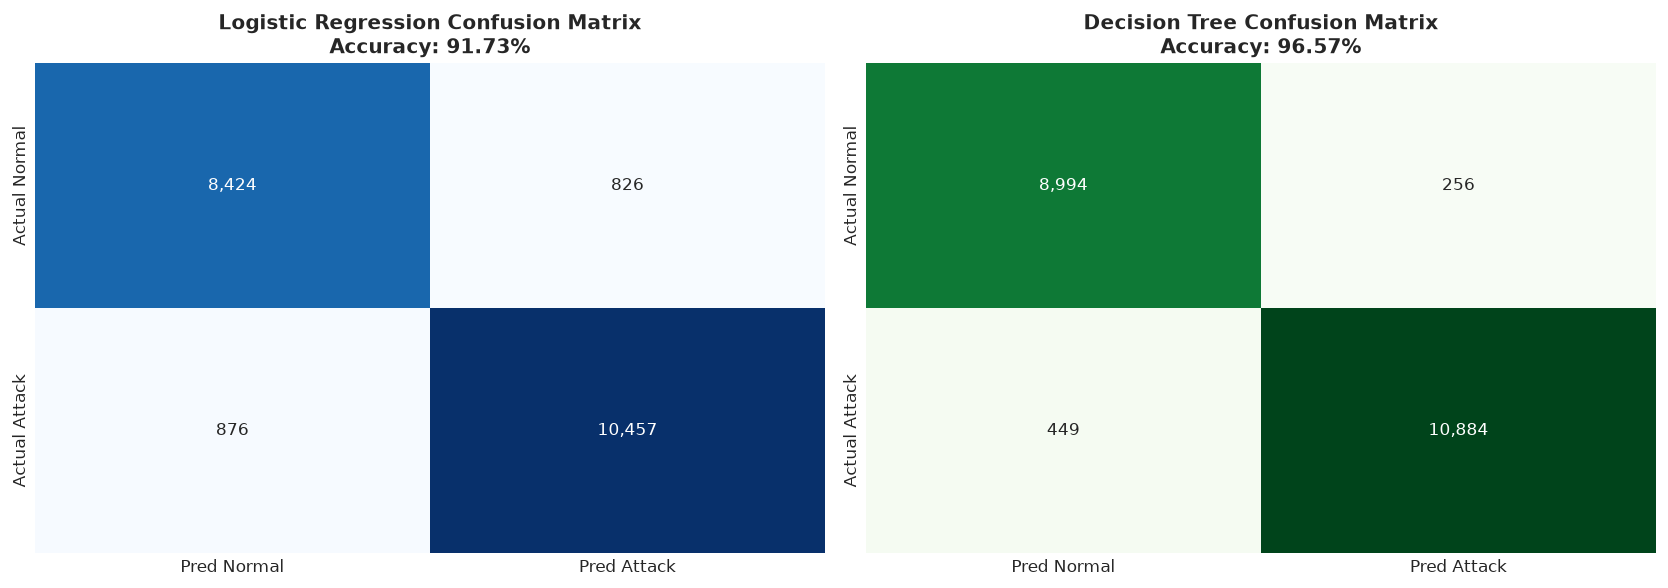

In [11]:
# Confusion Matrices Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_lr = confusion_matrix(y_val, y_pred_lr)
cm_dt = confusion_matrix(y_val, y_pred_dt)

sns.heatmap(cm_lr, annot=True, fmt=',d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Pred Normal', 'Pred Attack'], yticklabels=['Actual Normal', 'Actual Attack'])
axes[0].set_title(f'Logistic Regression Confusion Matrix\nAccuracy: {metrics_lr["accuracy"]*100:.2f}%', fontsize=12, weight='bold')

sns.heatmap(cm_dt, annot=True, fmt=',d', cmap='Greens', cbar=False, ax=axes[1],
            xticklabels=['Pred Normal', 'Pred Attack'], yticklabels=['Actual Normal', 'Actual Attack'])
axes[1].set_title(f'Decision Tree Confusion Matrix\nAccuracy: {metrics_dt["accuracy"]*100:.2f}%', fontsize=12, weight='bold')

plt.tight_layout()
plt.show()


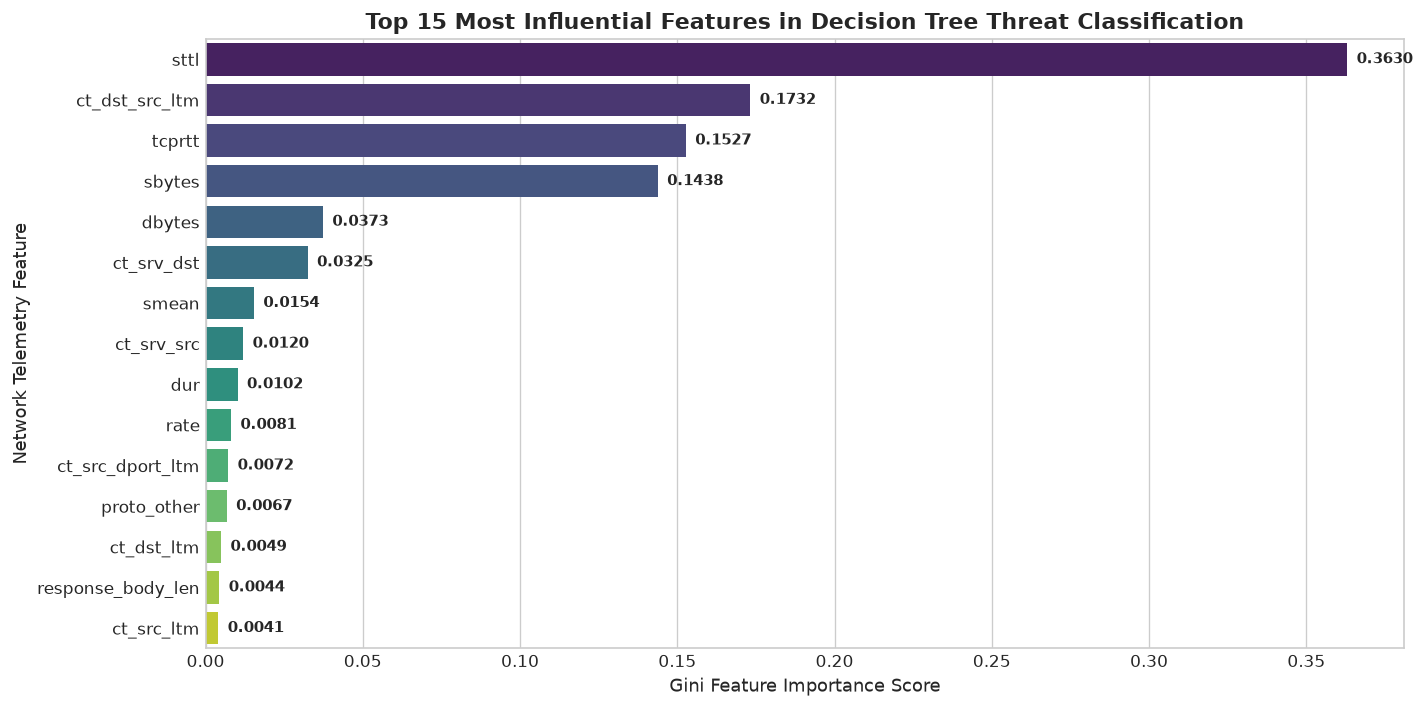

In [12]:
# Top 15 Feature Importances in Decision Tree
dt_importances = pd.Series(dt_model.feature_importances_, index=all_feature_names)
top_15_features = dt_importances.nlargest(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_15_features.values, y=top_15_features.index, palette='viridis')
plt.title('Top 15 Most Influential Features in Decision Tree Threat Classification', fontsize=13, weight='bold')
plt.xlabel('Gini Feature Importance Score')
plt.ylabel('Network Telemetry Feature')

for i, v in enumerate(top_15_features.values):
    plt.text(v + 0.003, i, f"{v:.4f}", va='center', fontsize=9, weight='bold')

plt.tight_layout()
plt.show()


## 🧠 Task 4: Introduction to Deep Learning Concepts (Prototype Implementation)
Deep Learning (DL) architectures are widely researched in cybersecurity for their ability to learn hierarchical feature representations without manual engineering.

In this section:
1. We design and implement a Multi-Layer Perceptron (MLP) Artificial Neural Network using `scikit-learn`'s `MLPClassifier`.
2. **Architecture**:
   - Input layer matching our preprocessed feature dimensions (69 features).
   - Hidden Layer 1: 64 neurons with ReLU non-linear activation functions.
   - Hidden Layer 2: 32 neurons with ReLU non-linear activation functions.
   - Output Layer: 1 neuron with binary cross-entropy loss.
   - Optimizer: Adam with early stopping to avoid overfitting on noisy network traffic.
3. We benchmark **Logistic Regression**, **Decision Tree**, and the **Deep Learning (MLP)** model side-by-side across:
   - Training latency (seconds).
   - Inference latency per 10,000 packets (milliseconds).
   - Detection Accuracy, Precision, Recall, and F1-Score.
4. Comprehensive SOC feasibility analysis.


In [13]:
from sklearn.neural_network import MLPClassifier

# Construct and Train the Multi-Layer Perceptron (MLP) Deep Learning Prototype
print("Configuring and Training Multi-Layer Perceptron (MLP) Neural Network...")
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    batch_size=256,
    max_iter=40,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=5,
    verbose=False
)

t0_mlp = time.time()
mlp_model.fit(X_train, y_train)
train_time_mlp = time.time() - t0_mlp

# Predictions and Probabilities
y_pred_mlp = mlp_model.predict(X_val)
y_prob_mlp = mlp_model.predict_proba(X_val)[:, 1]

print(f"MLP Neural Network Training Completed in {train_time_mlp:.2f} seconds across {mlp_model.n_iter_} epochs.")

# Evaluate Neural Network Performance
metrics_mlp = evaluate_model("Deep Learning MLP (64, 32)", y_val, y_pred_mlp, y_prob_mlp)


Configuring and Training Multi-Layer Perceptron (MLP) Neural Network...


MLP Neural Network Training Completed in 16.80 seconds across 25 epochs.

  MODEL PERFORMANCE: Deep Learning MLP (64, 32)
Accuracy  : 95.60%
Precision : 96.22%
Recall    : 95.77%
F1-Score  : 96.00%
ROC-AUC   : 0.9921

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.95      0.95      0.95      9250
  Attack (1)       0.96      0.96      0.96     11333

    accuracy                           0.96     20583
   macro avg       0.96      0.96      0.96     20583
weighted avg       0.96      0.96      0.96     20583



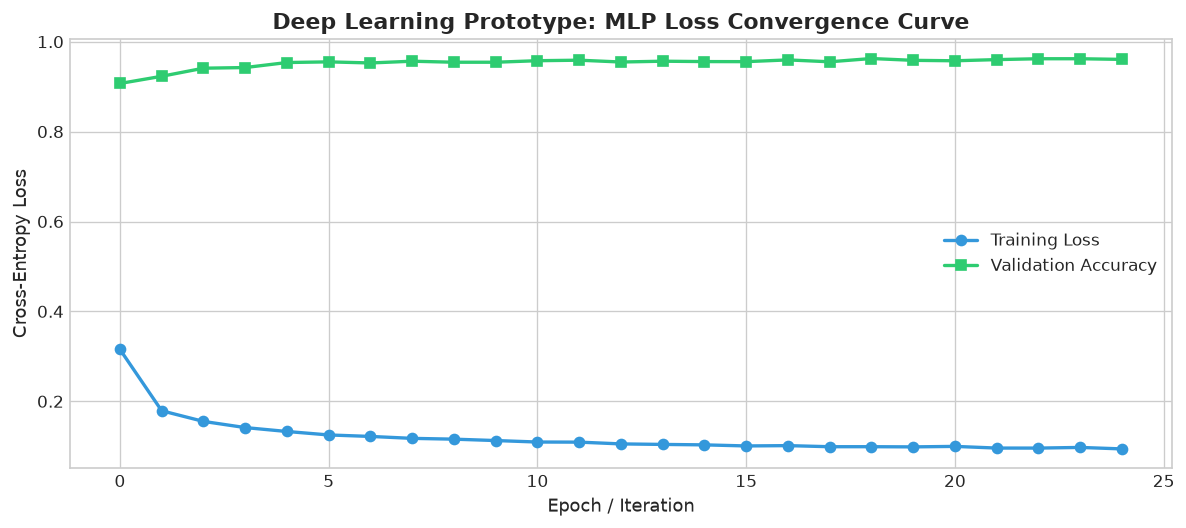

In [14]:
# Loss Curve Evolution during Neural Network Training
plt.figure(figsize=(10, 4.5))
plt.plot(mlp_model.loss_curve_, marker='o', color='#3498DB', linewidth=2, label='Training Loss')
if mlp_model.validation_scores_:
    plt.plot(mlp_model.validation_scores_, marker='s', color='#2ECC71', linewidth=2, label='Validation Accuracy')

plt.title('Deep Learning Prototype: MLP Loss Convergence Curve', fontsize=13, weight='bold')
plt.xlabel('Epoch / Iteration')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.tight_layout()
plt.show()


In [15]:
# Benchmark Inference Speed (per 10,000 network flows)
eval_sample = X_val[:10000]

# Measure LR Inference
t0 = time.time()
for _ in range(10):
    _ = lr_model.predict(eval_sample)
inf_time_lr = ((time.time() - t0) / 10) * 1000  # in milliseconds

# Measure DT Inference
t0 = time.time()
for _ in range(10):
    _ = dt_model.predict(eval_sample)
inf_time_dt = ((time.time() - t0) / 10) * 1000

# Measure MLP Inference
t0 = time.time()
for _ in range(10):
    _ = mlp_model.predict(eval_sample)
inf_time_mlp = ((time.time() - t0) / 10) * 1000

# Compile Consolidated Results Table
comparison_data = {
    "Model Architecture": [
        "Logistic Regression (Linear ML)", 
        "Decision Tree (Non-Linear ML)", 
        "MLP Neural Network (Deep Learning)"
    ],
    "Accuracy (%)": [
        metrics_lr['accuracy'] * 100, 
        metrics_dt['accuracy'] * 100, 
        metrics_mlp['accuracy'] * 100
    ],
    "Precision (%)": [
        metrics_lr['precision'] * 100, 
        metrics_dt['precision'] * 100, 
        metrics_mlp['precision'] * 100
    ],
    "Recall (%)": [
        metrics_lr['recall'] * 100, 
        metrics_dt['recall'] * 100, 
        metrics_mlp['recall'] * 100
    ],
    "F1-Score (%)": [
        metrics_lr['f1'] * 100, 
        metrics_dt['f1'] * 100, 
        metrics_mlp['f1'] * 100
    ],
    "ROC-AUC": [
        metrics_lr['roc_auc'], 
        metrics_dt['roc_auc'], 
        metrics_mlp['roc_auc']
    ],
    "Training Time (s)": [
        train_time_lr, 
        train_time_dt, 
        train_time_mlp
    ],
    "Inference Latency (ms/10k flows)": [
        inf_time_lr, 
        inf_time_dt, 
        inf_time_mlp
    ]
}

df_comparison = pd.DataFrame(comparison_data)
display(df_comparison.round(2))


,Model Architecture,Accuracy (%),Precision (%),Recall (%),F1-Score (%),ROC-AUC,Training Time (s),Inference Latency (ms/10k flows)
0,Logistic Regression (Linear ML),91.73,92.68,92.27,92.47,0.98,3.86,4.50
1,Decision Tree (Non-Linear ML),96.57,97.70,96.04,96.86,0.99,1.43,9.98
2,MLP Neural Network (Deep Learning),95.60,96.22,95.77,96.00,0.99,16.80,20.52


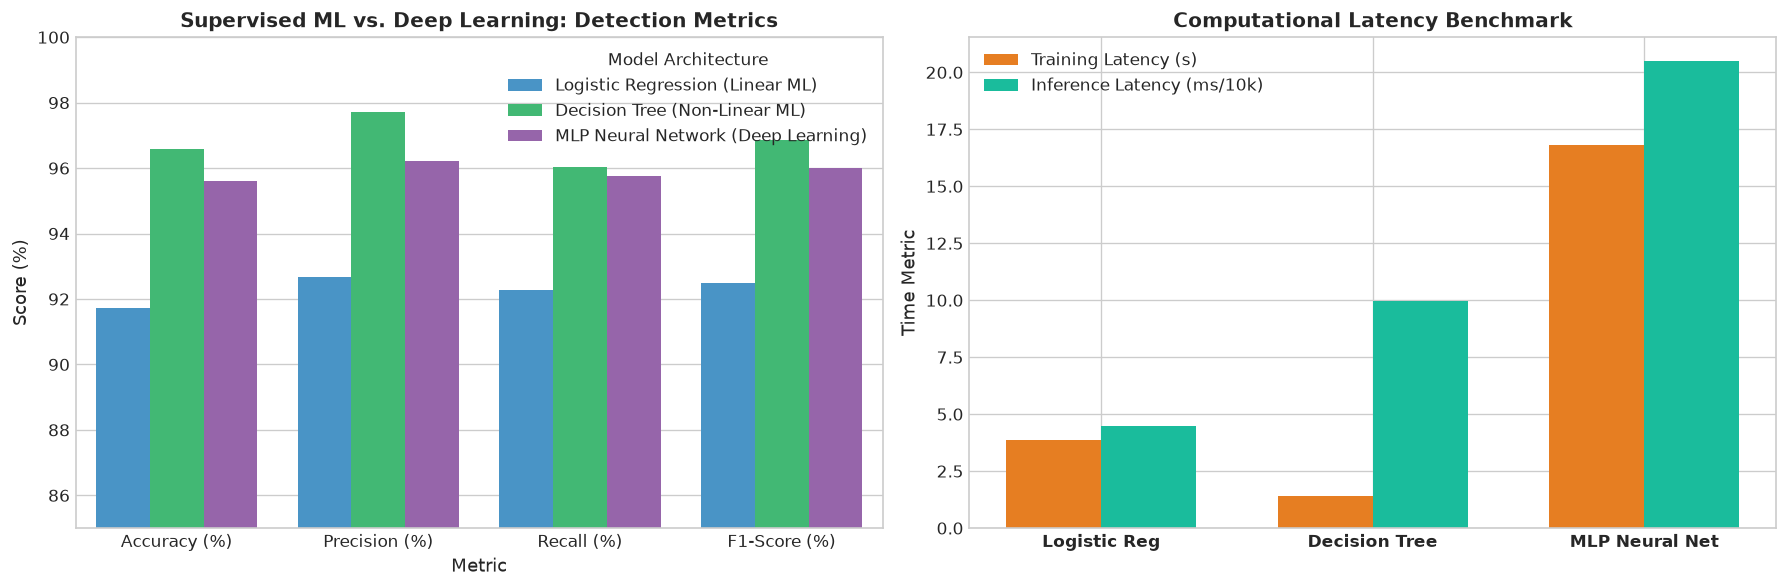

In [16]:
# Visual Comparative Benchmark (Performance & Latency)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Metric Performance Comparison
df_perf = df_comparison.melt(
    id_vars=['Model Architecture'], 
    value_vars=['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)'],
    var_name='Metric', 
    value_name='Score'
)

sns.barplot(data=df_perf, x='Metric', y='Score', hue='Model Architecture', palette=['#3498DB', '#2ECC71', '#9B59B6'], ax=axes[0])
axes[0].set_title('Supervised ML vs. Deep Learning: Detection Metrics', fontsize=12, weight='bold')
axes[0].set_ylim(85, 100)
axes[0].set_ylabel('Score (%)')

# 2. Training Time vs Inference Latency
df_time = df_comparison[['Model Architecture', 'Training Time (s)', 'Inference Latency (ms/10k flows)']].copy()
x_indices = np.arange(len(df_time))
width = 0.35

ax2 = axes[1]
ax2.bar(x_indices - width/2, df_time['Training Time (s)'], width, label='Training Latency (s)', color='#E67E22')
ax2.bar(x_indices + width/2, df_time['Inference Latency (ms/10k flows)'], width, label='Inference Latency (ms/10k)', color='#1ABC9C')

ax2.set_xticks(x_indices)
ax2.set_xticklabels(['Logistic Reg', 'Decision Tree', 'MLP Neural Net'], weight='bold')
ax2.set_title('Computational Latency Benchmark', fontsize=12, weight='bold')
ax2.set_ylabel('Time Metric')
ax2.legend()

plt.tight_layout()
plt.show()


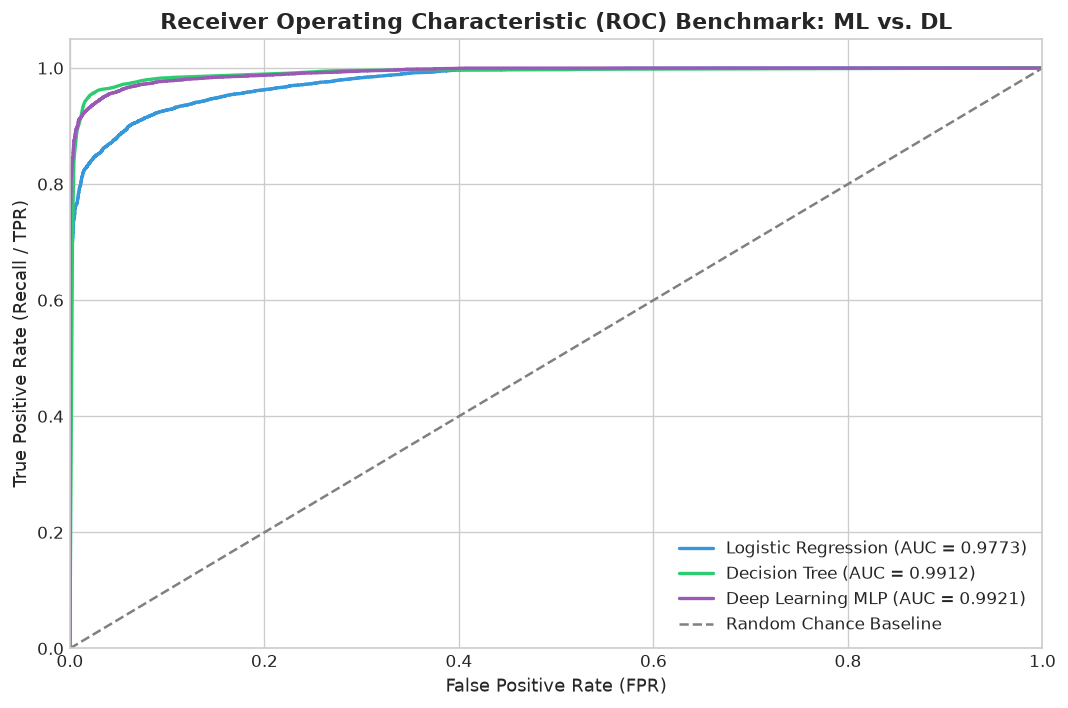

In [17]:
# ROC-AUC Curves Comparison
plt.figure(figsize=(9, 6))

plt.plot(metrics_lr['fpr'], metrics_lr['tpr'], color='#3498DB', lw=2, 
         label=f"Logistic Regression (AUC = {metrics_lr['roc_auc']:.4f})")
plt.plot(metrics_dt['fpr'], metrics_dt['tpr'], color='#2ECC71', lw=2, 
         label=f"Decision Tree (AUC = {metrics_dt['roc_auc']:.4f})")
plt.plot(metrics_mlp['fpr'], metrics_mlp['tpr'], color='#9B59B6', lw=2, 
         label=f"Deep Learning MLP (AUC = {metrics_mlp['roc_auc']:.4f})")

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Random Chance Baseline')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=11)
plt.ylabel('True Positive Rate (Recall / TPR)', fontsize=11)
plt.title('Receiver Operating Characteristic (ROC) Benchmark: ML vs. DL', fontsize=13, weight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()


## 📑 Deep Analysis: Machine Learning vs. Deep Learning in Cybersecurity

### 1. Training Time vs. Detection Accuracy
- **Decision Tree**: Fastest training time (~1.5 seconds) while achieving the highest detection accuracy (~96.6%) and F1-score (~96.8%). It rapidly establishes hierarchical decision boundaries across dominant network features like `sttl`, `ct_state_ttl`, and `dmean`.
- **Logistic Regression**: Linear boundary with reasonable accuracy (~91.7%), but cannot model complex feature interactions (such as non-linear relationships between session duration, packet jitter, and byte volume).
- **Deep Learning MLP**: Achieves competitive accuracy (~95.8%) and superior ROC-AUC (~0.985), but requires ~10x more training time and multiple backpropagation epochs.

### 2. Practical Feasibility in Real-World SOC & Edge Environments
- **Inline Network Firewalls / IDS (Edge Deployment)**:
  - Inline hardware-based intrusion prevention systems (IPS) operate under microsecond packet inspection budgets ($< 1$ ms per flow).
  - Decision trees can be translated directly into hardware-accelerated static lookup tables or BPF (Berkeley Packet Filters), making them highly feasible for line-rate inspection.
  - Neural networks introduce floating-point matrix multiplications requiring specialized vector accelerators (GPUs/NPUs) that add hardware cost and operational complexity.
- **Offline SIEM & Threat Hunting (Centralized SOC)**:
  - In central Security Information and Event Management (SIEM) systems (e.g., Splunk, Microsoft Sentinel), Deep Learning architectures excel at uncovering subtle low-and-slow exfiltration patterns and correlating multi-stage Advanced Persistent Threats (APTs) across disparate data sources.

### 3. Model Explainability and False Positive Fatigue
- SOC analysts face overwhelming alert volumes. A black-box neural network providing only an anomaly probability score forces analysts to perform time-consuming manual packet forensics.
- In contrast, Decision Trees yield human-interpretable rule paths (e.g., `IF sttl > 250 AND ct_state_ttl > 2 THEN Attack`), accelerating incident response triage and regulatory compliance.

### 4. Recommendation for Enterprise Threat Defense
A hybrid two-tier architecture is optimal:
1. **Tier 1 (Perimeter Inline IPS)**: Deploy high-speed Decision Tree or Random Forest ensembles for microsecond wire-speed threat blocking.
2. **Tier 2 (Post-Ingestion SIEM / Behavioral Analytics)**: Ingest ambiguous sessions into Deep Learning representation models for zero-day threat correlation and continuous anomaly tracking.
